# Task 2 - Detection

## Import and setup

In [2]:
!pip install opencv-python numpy matplotlib open3d Pillow scipy sympy easydict torch pillow protobuf==3.20.0 shapely ipykernel ipywidgets open3d

In [3]:
import os

import cv2
from IPython.display import display
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import open3d as o3d
from PIL import Image
from scipy.spatial.transform import Rotation
from sympy import Matrix
from easydict import EasyDict as edict
from typing import Tuple

import tools.dataset_tools as dataset_tools
from tools.frame_pb2 import Frame
import tools.plot_tools as plot_tools
import torch


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Process raw LiDAR point cloud data

In [4]:
frame = dataset_tools.read_frame("dataset/data_2/frame_0.pb")

# print number of lidars
print(f"Number of lidars: {len(frame.lidars)}")
lidar = frame.lidars[0]

# Extract pointcloud
pcl = dataset_tools.decode_lidar(lidar)
print(f"Pointcloud shape: {pcl.shape}")

Number of lidars: 1
Pointcloud shape: (196608, 4)


## Convert to Bird's Eye View representation

In [5]:
def visualize_bev(bev):
    """
    Visualize Bird's Eye View (BEV) data both as a combined map and individual channels
    
    Args:
        bev: numpy array of shape (channels, height, width)
    """
    # Create a figure with two rows
    plt.figure(figsize=(15, 10))
    
    # Plot combined BEV map
    plt.subplot(2, 1, 1)
    bev_map_display = np.transpose(bev, (1, 2, 0))
    plt.imshow(bev_map_display)
    plt.colorbar()
    plt.title("Combined Bird's Eye View Map")
    
    # Plot individual channels
    plt.subplot(2, 1, 2)
    titles = ['Height', 'Intensity', 'Density']
    for i, title in enumerate(titles):
        plt.subplot(2, 3, i + 4)  # Position in bottom row
        im = plt.imshow(bev_map_display[:,:,i])
        plt.title(title)
        plt.colorbar(im)
    
    # plt.tight_layout()
    plt.show()

In [6]:
config = edict()
config.lims = edict()
config.lims.x = [0, 50]
config.lims.y = [-25, 25]
config.lims.z = [-1, 3]
config.lims.intensity = [0, 1]
config.bev_height = 608
config.bev_width = 608

BEV shape: (3, 608, 608)


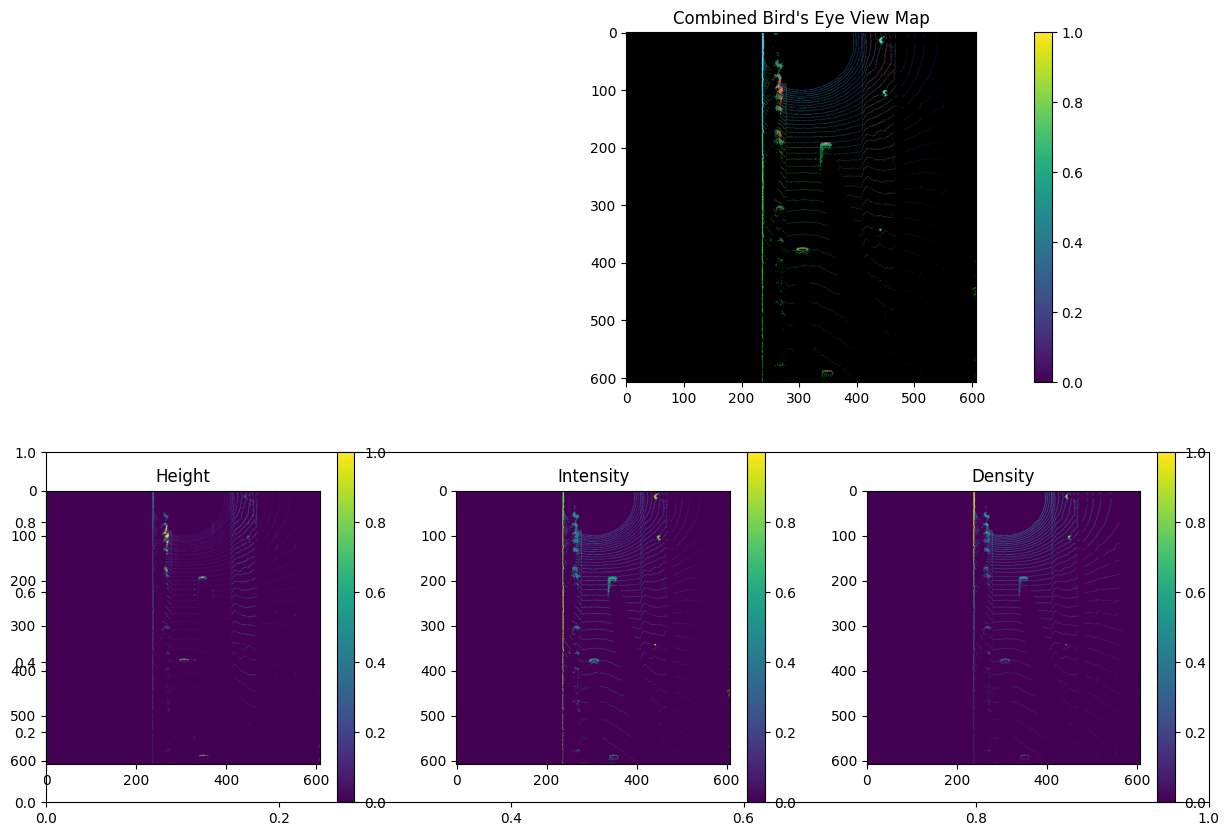

In [10]:

def pcl_to_bev(pcl:np.ndarray, configs: edict) -> np.ndarray:
    """Computes the bev map of a given pointcloud. 
    
    For generality, this method can return the bev map of the available 
    channels listed in '''BEVConfig.VALID_CHANNELS'''. 

    Parameters
    ----------
        pcl (np.ndarray): pointcloud as a numpy array of shape [n_points, m_channles] 
        configs (Dict): configuration parameters of the resulting bev_map

    Returns
    -------
        bev_map (np.ndarray): bev_map as numpy array of shape [len(config.channels), configs.bev_height, configs.bev_width ]
    """
    pcl = pcl.copy()
    # Step 1:
    # remove lidar points outside detection area
    mask = np.where((pcl[:, 0] >= configs.lims.x[0]) & (pcl[:, 0] <= configs.lims.x[1]) &
                    (pcl[:, 1] >= configs.lims.y[0]) & (pcl[:, 1] <= configs.lims.y[1]) &
                    (pcl[:, 2] >= configs.lims.z[0]) & (pcl[:, 2] <= configs.lims.z[1]))
    pcl = pcl[mask]
    # shift level of ground plane to avoid flipping from 0 to 255 for neighboring pixels
    pcl[:, 2] = pcl[:, 2] - configs.lims.z[0]
    # limit intensity values
    pcl[pcl[:,3]<configs.lims.intensity[0],3] = configs.lims.intensity[0]
    pcl[pcl[:,3]>configs.lims.intensity[1],3] = configs.lims.intensity[1]  

    # Step 2:
    # Convert sensor coordinates to bev-map coordinates (center is bottom-middle)
    # compute bev-map discretization by dividing x-range by the bev-image height
    bev_x_discret = (configs.lims.x[1] - configs.lims.x[0]) / configs.bev_height
    bev_y_discret = (configs.lims.y[1] - configs.lims.y[0]) / configs.bev_width
    
    # Step 3:
    ## transform all metrix x-coordinates into bev-image coordinates    
    pcl[:, 0] = np.int_(np.floor(pcl[:, 0] / bev_x_discret))
    # transform all y-coordinates making sure that no negative bev-coordinates occur
    pcl[:, 1] = np.int_(np.floor(pcl[:, 1] / bev_y_discret) + (configs.bev_width + 1) / 2) 
    
    # Step 4:
    # Sort poitncloud by x, y, and then z
    pcl_height_sorted, counts = sort_and_map(pcl, 2, return_counts=True)
    xs = np.int_(pcl_height_sorted[:, 0])
    ys = np.int_(pcl_height_sorted[:, 1])
    
    # Step 5:
    # Compute height channel
    normalized_height = pcl_height_sorted[:, 2]/float(np.abs(configs.lims.z[1] - configs.lims.z[0]))
    # Fill height map
    height_map = np.zeros((configs.bev_height + 1, configs.bev_width + 1))
    height_map[xs,ys] = normalized_height
    
    # Step 6:
    # Compute density channel
    normalized_density = np.minimum(1.0, np.log(counts + 1) / np.log(64))
    # Fill density map
    density_map = np.zeros((configs.bev_height + 1, configs.bev_width + 1))
    density_map[xs,ys] = normalized_density

    # Step 7:
    # Filter intensities that are bi    
    pcl_int_sorted, _ = sort_and_map(pcl, 3, return_counts=False)
    xs = np.int_(pcl_int_sorted[:, 0])
    ys = np.int_(pcl_int_sorted[:, 1])
    
    normalized_int = pcl_int_sorted[:, 3]/(np.amax(pcl_int_sorted[:, 3])-np.amin(pcl_int_sorted[:, 3]))

    intensity_map = np.zeros((configs.bev_height + 1, configs.bev_width + 1))
    intensity_map[xs,ys] = normalized_int

    # Step 8:    
    # Create BEV map
    bev_map = np.zeros((3, configs.bev_height, configs.bev_width))
    # Fill BEV 
    bev_map[2,:,:] = density_map[:configs.bev_height, :configs.bev_width]
    bev_map[1,:,:] = height_map[:configs.bev_height, :configs.bev_width]
    bev_map[0,:,:] = intensity_map[:configs.bev_height, :configs.bev_width]
 
    return bev_map

def sort_and_map(pcl: np.ndarray, channel_index: int, return_counts:bool=False) ->Tuple[np.ndarray,np.ndarray]:
    """Function to re-arrange elements in poincloud by sorting first by x, then y, then -channel.
    This function allows users to map a pointcloud channel to a top view image (in z axis) of that channel.

    Parameters
    ----------
        pcl (np.ndarray): Input pointcloud of of shape [n_points, m_channles]
        channel_index (int): Index of channel to take into account as third factor, 
                             when sorting the pointcloud.
        return_counts (bool): True to return the counts on points per cell. Used for density channel
    Returns
     ----------
       pcl_sorted (np.ndarray): Sorted poincloud by $x$, then $y$, then $-channel$. This function return only
                                one point per unique pair ($x$,$y$) with the maximum value in the $channel$ 
                                coordinate.
       counts (np.ndarray): Return the amount of points per unique pair ($x$,$y$) if return counts is true
                            or None otherwise.
       
    """

    idx= np.lexsort((-pcl[:, channel_index], pcl[:, 1], pcl[:, 0]))
    pcl_sorted = pcl[idx]
    counts = None
    # extract all points with identical x and y such that only the maximum value of the channel is kept
    if return_counts:
        _, indices, counts = np.unique(pcl_sorted[:, 0:2], axis=0, return_index=True, return_counts=return_counts)
    else:
        _, indices = np.unique(pcl_sorted[:, 0:2], axis=0, return_index=True)
    return (pcl_sorted[indices], counts)

# Test the function
bev = pcl_to_bev(pcl, config)
print(f"BEV shape: {bev.shape}")

# Visualize BEV channels
visualize_bev(bev)

## Feed into deep learning model to detect vehicles

## Feed into deep learning model to detect vehicles

## Evaluate detection performance